In [3]:
!pip install -q ultralytics==8.4.79
import torch
import ultralytics
from ultralytics import YOLO


print("GPU:", torch.cuda.get_device_name(0))
print("Ultralytics:", ultralytics.__version__)

GPU: Tesla T4
Ultralytics: 8.4.79


In [4]:
from google.colab import drive
from pathlib import Path
from zipfile import ZipFile


drive.mount("/content/drive")
zip_path=Path("/content/drive/MyDrive/rock_project/Rock2026812.v7-rock_detection_509_v3.yolov11.zip")
dataset_path= Path("/content/rock_detection_509_v7")

with ZipFile(zip_path,"r") as zip_file:
    zip_file.extractall(dataset_path)

print("Dataset:", dataset_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset: /content/rock_detection_509_v7


In [5]:
data_yaml = dataset_path / "data.yaml"
yaml_text=(
    "path: /content/rock_detection_509_v7\n"
    "train: train/images\n"
    "val: valid/images\n"
    "test: test/images\n"
    "nc: 1\n"
    "names: {0: rock}\n"
)

data_yaml.write_text(yaml_text,encoding="utf-8")

print(data_yaml.read_text(encoding="utf-8"))

path: /content/rock_detection_509_v7
train: train/images
val: valid/images
test: test/images
nc: 1
names: {0: rock}



In [6]:
total_image = 0
total_box = 0
image_type = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

for split in ["train", "valid", "test"]:
    image_dir = dataset_path / split / "images"
    label_dir = dataset_path / split / "labels"

    images = [
        file for file in image_dir.iterdir()
        if file.is_file() and file.suffix.lower() in image_type
    ]

    labels = list(label_dir.glob("*.txt"))
    box_count = 0
    for label_file in labels:
        lines = label_file.read_text(
            encoding="utf-8"
        ).splitlines()

        box_count += len([
            line for line in lines
            if line.strip()
        ])

    print(
        f"{split}: images={len(images)}, "
        f"labels={len(labels)}, "
        f"boxes={box_count}"
    )
    total_image=len(images)+total_image
    total_box=total_box+box_count

print("Total images:", total_image)
print("Total boxes:", total_box)

train: images=359, labels=359, boxes=496
valid: images=74, labels=74, boxes=97
test: images=76, labels=76, boxes=97
Total images: 509
Total boxes: 690


In [7]:
model=YOLO("yolo11n.pt")

train_results = model.train(
    data=str(data_yaml),
    epochs=100,
    patience=20,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    seed=42,
    deterministic=True,
    hsv_h=0.015,
    hsv_s=0.40,
    hsv_v=0.30,
    optimizer="auto",
    amp=True,

    degrees=5.0,
    translate=0.08,
    scale=0.20,
    shear=0.0,
    perspective=0.0,
    flipud=0.0,
    fliplr=0.5,
    mosaic=0.5,
    mixup=0.0,
    close_mosaic=10,

    project=str(Path("/content/drive/MyDrive/rock_project/runs")),
    name="yolo11n_detect_640_v7",
    exist_ok=False,
    plots=True,
    save=True
)

run_path = Path(train_results.save_dir)
best_pt=run_path/"weights"/"best.pt"
last_pt= run_path /"weights"/"last.pt"

print("Training result location:", run_path)
print("Last model: ", last_pt)
print("Best model: ", best_pt)

New https://pypi.org/project/ultralytics/8.4.137 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.79 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/rock_detection_509_v7/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.4, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.9

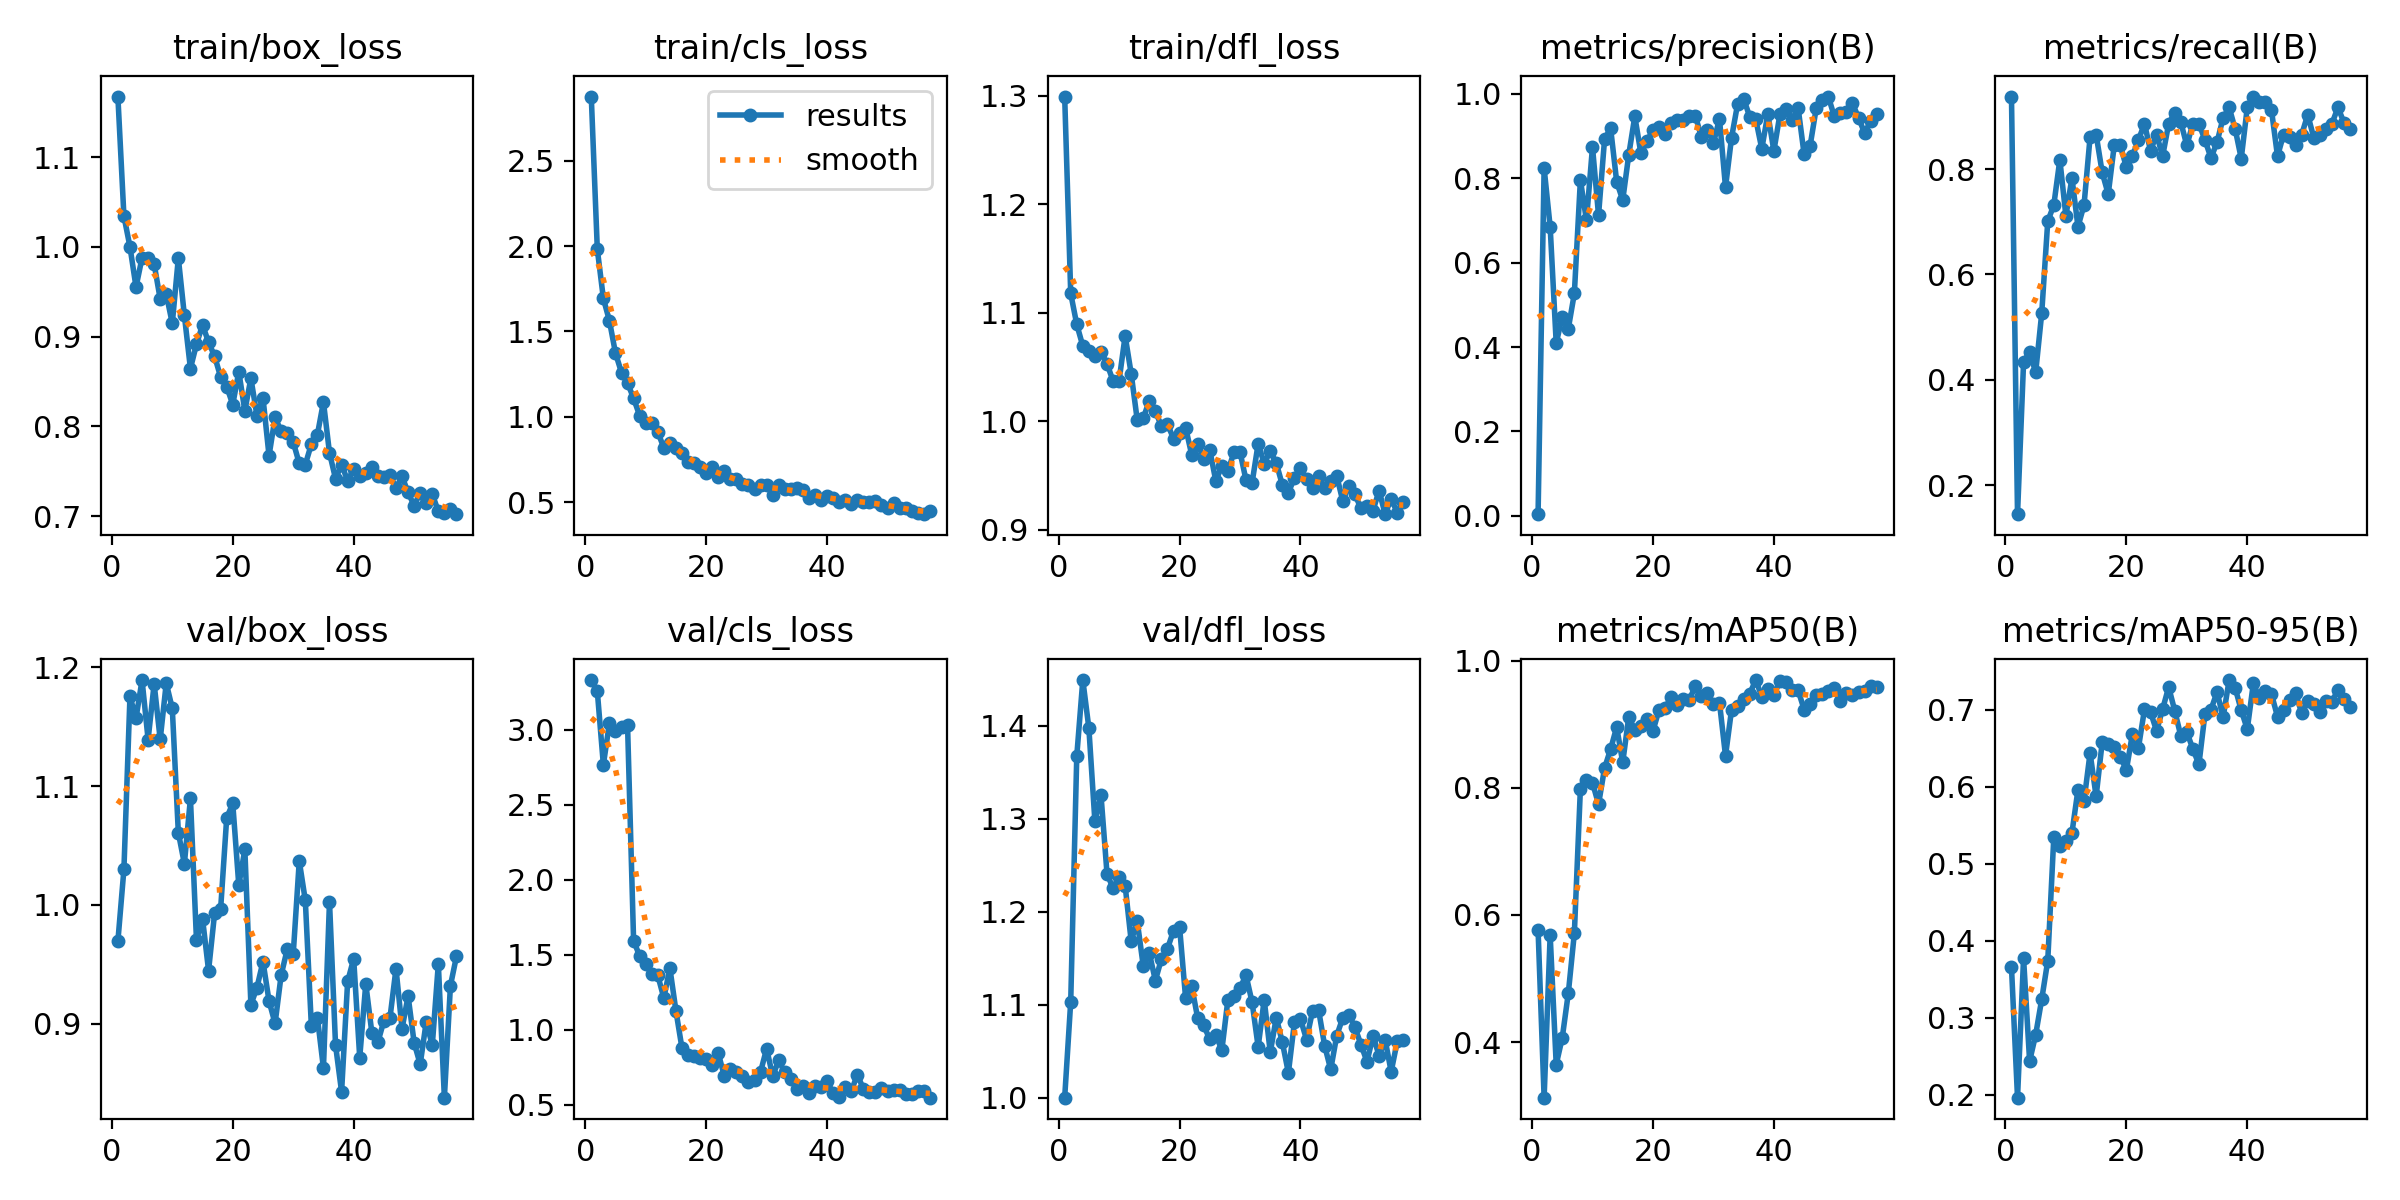

In [8]:
from IPython.display import display,Image

display(Image(filename=str(run_path/"results.png")))

In [9]:
best_model = YOLO(str(best_pt))

val_metrics = best_model.val(
    data=str(data_yaml),
    split="val",
    imgsz=640,
    batch=16,
    device=0,
    plots=True,
    project=str(Path("/content/drive/MyDrive/rock_project/runs")/"validation"),
    name="yolo11n_detect_640_v7_val",
    exist_ok=True
)

print("Validation results")
print(f"Precision : {val_metrics.box.mp:.4f}")
print(f"Recall    : {val_metrics.box.mr:.4f}")
print(f"mAP50     : {val_metrics.box.map50:.4f}")
print(f"mAP50-95  : {val_metrics.box.map:.4f}")

Ultralytics 8.4.79 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4055.3±539.5 MB/s, size: 2542.5 KB)
val: Scanning /content/rock_detection_509_v7/valid/labels.cache... 74 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 74/74 28.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.4s/it 7.1s
                   all         74         97      0.939      0.918       0.97      0.738
Speed: 5.0ms preprocess, 14.8ms inference, 0.0ms loss, 3.1ms postprocess per image
Results saved to /content/drive/MyDrive/rock_project/runs/validation/yolo11n_detect_640_v7_val
Validation results
Precision : 0.9391
Recall    : 0.9175
mAP50     : 0.9700
mAP50-95  : 0.7384


In [10]:
test_metrics = best_model.val(
    data=str(data_yaml),
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    plots=True,
    project=str(Path("/content/drive/MyDrive/rock_project/runs")/"test"),
    name="yolo11n_detect_640_v7_test",
    exist_ok=True
)

print("Final test results")
print(f"Precision : {test_metrics.box.mp:.4f}")
print(f"Recall    : {test_metrics.box.mr:.4f}")
print(f"mAP50     : {test_metrics.box.map50:.4f}")
print(f"mAP50-95  : {test_metrics.box.map:.4f}")

Ultralytics 8.4.79 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 259.0±43.8 MB/s, size: 3169.5 KB)
val: Scanning /content/rock_detection_509_v7/test/labels... 76 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 76/76 640.7it/s 0.1s
val: New cache created: /content/rock_detection_509_v7/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.8s/it 9.1s
                   all         76         97      0.987      0.866      0.928      0.746
Speed: 4.4ms preprocess, 5.9ms inference, 0.0ms loss, 2.6ms postprocess per image
Results saved to /content/drive/MyDrive/rock_project/runs/test/yolo11n_detect_640_v7_test
Final test results
Precision : 0.9867
Recall    : 0.8660
mAP50     : 0.9278
mAP50-95  : 0.7456


In [11]:
from google.colab import files

files.download(str(best_pt))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
import shutil
export_path = Path("/content/yolo11n_detect_640_v7_results")


if export_path.exists():
    shutil.rmtree(export_path)

export_path.mkdir()

shutil.copytree(
    run_path,
    export_path/"training"
)

shutil.copytree(
    Path("/content/drive/MyDrive/rock_project/runs")/"validation"/ "yolo11n_detect_640_v7_val",
    export_path/"validation"
)

shutil.copytree(
    Path("/content/drive/MyDrive/rock_project/runs")/"test"/"yolo11n_detect_640_v7_test",
    export_path/"test"
)

zip_file = shutil.make_archive(
    str(export_path),
    "zip",
    root_dir=str(export_path)
)

files.download("/content/yolo11n_detect_640_v7_results.zip")
print("Results:", zip_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Results: /content/yolo11n_detect_640_v7_results.zip
